Imports

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

Configuration

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 5

DATASET_DIR = "../dataset_stage2"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

Data Generators (with augmentation)

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Load Datasets

In [4]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 3200 images belonging to 5 classes.
Found 400 images belonging to 5 classes.
Found 400 images belonging to 5 classes.


Class Mapping (IMPORTANT)

Expected Output:
{'glass': 0, 'metal': 1, 'paper': 2, 'plastic': 3, 'residual': 4}

In [5]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'glass': 0, 'metal': 1, 'paper': 2, 'plastic': 3, 'residual': 4}


Load Pretrained MobileNetV3

In [6]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

Freeze Base Model

In [7]:
for layer in base_model.layers:
    layer.trainable = False

Add Classification Head (Stage 2 = Softmax)

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

Compile Model

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

Model Summary

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,243,653 (12.37 MB)

 Trainable params: 247,301 (966.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Train the Model

In [11]:
checkpoint_path = "model/stage2_mobilenetv3_best.h5"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4122 - loss: 1.5964 - precision: 0.4567 - recall: 0.3018

100/100 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.5309 - loss: 1.2383 - precision: 0.5994 - recall: 0.4288 - val_accuracy: 0.8025 - val_loss: 0.5679 - val_precision: 0.8705 - val_recall: 0.7225 - learning_rate: 1.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7540 - loss: 0.6897 - precision: 0.8110 - recall: 0.6842

100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7672 - loss: 0.6401 - precision: 0.8244 - recall: 0.7084 - val_accuracy: 0.8450 - val_loss: 0.4076 - val_precision: 0.8933 - val_recall: 0.7950 - learning_rate: 1.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8178 - loss: 0.5173 - precision: 0.8558 - recall: 0.7756

100/100 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8184 - loss: 0.5083 - precision: 0.8527 - recall: 0.7778 - val_accuracy: 0.8825 - val_loss: 0.3380 - val_precision: 0.9103 - val_recall: 0.8375 - learning_rate: 1.0000e-04
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8613 - loss: 0.4126 - precision: 0.8798 - recall: 0.8249

100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8537 - loss: 0.4155 - precision: 0.8791 - recall: 0.8225 - val_accuracy: 0.8975 - val_loss: 0.2983 - val_precision: 0.9249 - val_recall: 0.8625 - learning_rate: 1.0000e-04
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8594 - loss: 0.4021 - precision: 0.8849 - recall: 0.8281

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9534 - loss: 0.1496 - precision: 0.9614 - recall: 0.9428 - val_accuracy: 0.9500 - val_loss: 0.1712 - val_precision: 0.9593 - val_recall: 0.9425 - learning_rate: 1.0000e-04
Epoch 17/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9483 - loss: 0.1559 - precision: 0.9549 - recall: 0.9370

100/100 ━━━━━━━━━━━━━━━━━━━━ 394s 4s/step - accuracy: 0.9553 - loss: 0.1396 - precision: 0.9609 - recall: 0.9444 - val_accuracy: 0.9475 - val_loss: 0.1660 - val_precision: 0.9543 - val_recall: 0.9400 - learning_rate: 1.0000e-04
Epoch 18/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9492 - loss: 0.1426 - precision: 0.9576 - recall: 0.9427

100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9484 - loss: 0.1452 - precision: 0.9580 - recall: 0.9413 - val_accuracy: 0.9500 - val_loss: 0.1658 - val_precision: 0.9520 - val_recall: 0.9425 - learning_rate: 1.0000e-04
Epoch 19/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9529 - loss: 0.1412 - precision: 0.9581 - recall: 0.9461

100/100 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9541 - loss: 0.1389 - precision: 0.9600 - recall: 0.9456 - val_accuracy: 0.9550 - val_loss: 0.1546 - val_precision: 0.9618 - val_recall: 0.9450 - learning_rate: 1.0000e-04
Epoch 20/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9556 - loss: 0.1308 - precision: 0.9640 - recall: 0.9479

100/100 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9597 - loss: 0.1257 - precision: 0.9673 - recall: 0.9516 - val_accuracy: 0.9550 - val_loss: 0.1540 - val_precision: 0.9644 - val_recall: 0.9475 - learning_rate: 1.0000e-04


Plot Accuracy & Loss

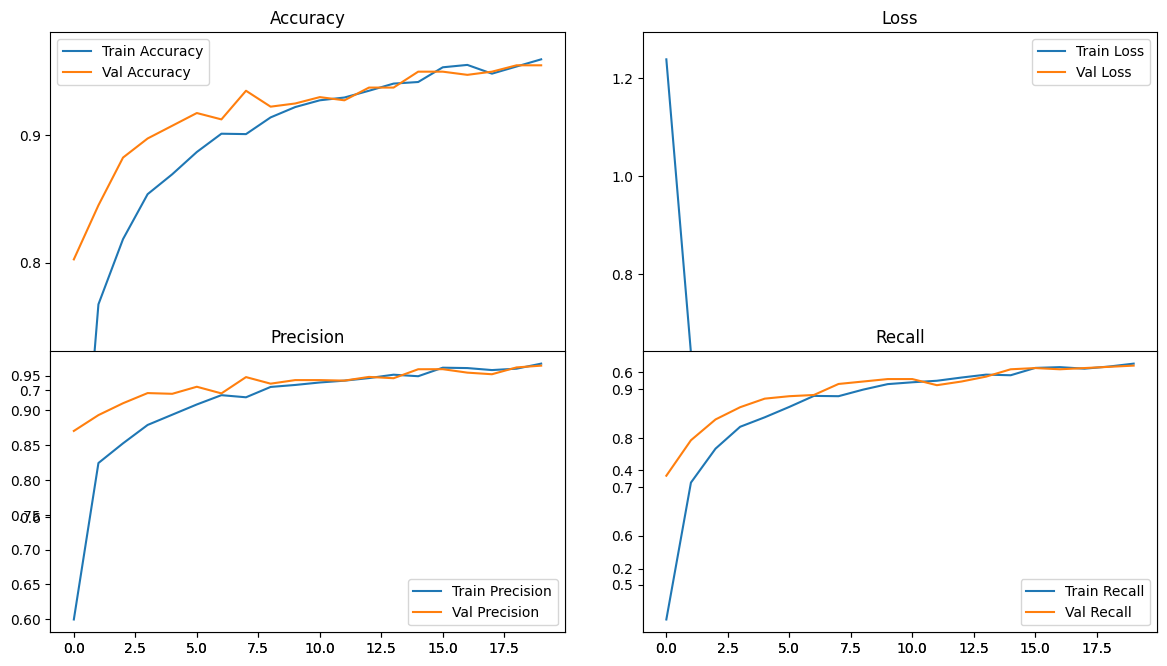

In [12]:
plt.figure(figsize=(12, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.legend()
plt.title("Precision")

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 862ms/step


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (5).

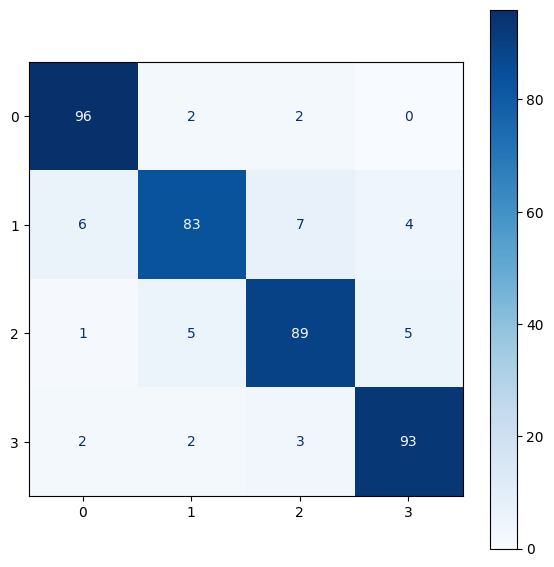

In [ ]:
# Ground-truth integer labels
y_true = test_generator.classes  # shape: (num_samples,)

# Predict probabilities for all test images
y_prob = model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Class names in correct index order
# e.g. {'glass':0, 'metal':1, 'paper':2, 'plastic':3, 'residual':4}
class_indices = test_generator.class_indices
classes = [cls for cls, idx in sorted(class_indices.items(), key=lambda x: x[1])]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)

ax.set_title("Stage 2 – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Evaluate on Test Set

In [14]:
results = model.evaluate(test_generator, return_dict=True)

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9025 - loss: 0.2434 - precision: 0.9130 - recall: 0.8925
